# Can AI Save Lives? — An Intelligent Clinical Early Warning System
### Deep Learning · Complex Computing Problem · Implementation Notebook

This notebook builds **three generations** of deterioration-risk models on top of one clinical
dataset, each one fixing a limitation of the last:

| Gen | Idea | Models |
|----|------|--------|
| 1 | A snapshot is enough? | DNN baseline (SGD vs Adam, Dropout/BatchNorm) |
| 2 | Risk is a *story over time* | LSTM, GRU, Bidirectional-LSTM |
| 3 | Notes tell what numbers can't | ClinicalBERT (frozen head vs full fine-tune) + attention |

---
### How to run
Open in **Google Colab** → `Runtime > Change runtime type > GPU (T4)` → `Runtime > Run all`.
Everything (dataset download, training, plots) runs top-to-bottom with no manual steps.

### Two design decisions you should know about up front
1. **Dataset = PhysioNet/CinC 2019 Sepsis Challenge.** It's fully public (one `wget`), gives us
   hourly vital signs + labs per patient, and a `SepsisLabel`. We frame the task as a *per-patient*
   binary problem: *did this patient ever cross into the sepsis-onset window?* That's our
   "deterioration" target.
2. **The notes for Generation 3.** The sepsis dataset has **no free text**, and MIMIC-III notes are
   behind credentialed access (not a one-command download). So we **synthesise a nursing/physician
   shift note for each patient from their own real vitals and labs** (e.g. a febrile, tachycardic,
   hypotensive patient gets a note that says so). This is a *disclosed* substitution — it keeps the
   whole pipeline reproducible from a single public dataset, and it still produces real clinical
   vocabulary for ClinicalBERT to attend to. If you have MIMIC-III access, you can drop real notes
   straight into the `notes` column and the rest of the code is unchanged.


## 0 · Environment
Colab already has torch/sklearn; we only need HuggingFace `transformers`.

In [1]:
# Colab ships with torch + sklearn. We only add transformers (for ClinicalBERT) and bertviz (optional).
!pip -q install transformers==4.44.2 bertviz 2>/dev/null

import os, time, glob, random, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# One seed everywhere so results are reproducible when you re-run.
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on:", DEVICE)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 7.4 MB/s eta 0:00:00
Running on: cuda


## 1 · One-command dataset download
PhysioNet hosts one pipe-separated `.psv` file per patient. The line below pulls **training set A**
(20,336 patients, ~20 MB) straight from PhysioNet — no login, no Kaggle token.

In [3]:
# --- ONE COMMAND: grab the whole sepsis cohort from PhysioNet ---------------
# -r recursive, -np stay inside this folder, -nH/-cut-dirs flatten the path, -np no parent.
!wget -r -N -c -np -nH --cut-dirs=5 -R "index.html*" -q \
  https://physionet.org/files/challenge-2019/1.0.0/training/training_setA/ -P data/

psv_files = sorted(glob.glob("data/**/*.psv", recursive=True))
print(f"Downloaded {len(psv_files)} patient files")
# Peek at one patient so we can see the raw structure (hourly rows, lots of NaNs).
pd.read_csv(psv_files[0], sep="|").head()

^C
Downloaded 4775 patient files


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0


## 2 · Preprocessing
For every patient we:
* read their hourly record,
* derive the **per-patient label** (`1` if `SepsisLabel` is ever 1 — i.e. they deteriorated),
* keep the eight most-populated vitals/labs (the rest are >90% missing and not worth it),
* build a **fixed 24-hour window** for the sequence models (pad short stays, take the last 24h of long ones),
* **impute** missing values by per-patient forward-fill then a global median,
* **normalise** with a `StandardScaler` *fit on the training split only* (no leakage),
* encode `Gender` as the 0/1 it already is.

> **SUBSAMPLE** keeps the demo fast. Set it to `None` to use every patient for your real run.

In [5]:
SUBSAMPLE = 6000        # set to None to use all ~20k patients
WINDOW    = 24          # hours of history fed to the sequence models
# The 8 columns that are actually populated often enough to be useful.
VITALS = ["HR", "O2Sat", "Temp", "SBP", "MAP", "Resp", "Lactate", "WBC"]

files = psv_files if SUBSAMPLE is None else psv_files[:SUBSAMPLE]

seqs, statics, labels, agg_rows = [], [], [], []
for f in files:
    df = pd.read_csv(f, sep="|")
    # A patient "deteriorated" if sepsis onset is flagged anywhere in their stay.
    label = int(df["SepsisLabel"].max() == 1)

    v = df[VITALS].copy()
    v = v.ffill().bfill()                       # carry the last known reading forward (clinically sensible)
    # Take the final 24h — that's the window a live monitor would actually have.
    v = v.tail(WINDOW)
    if len(v) < WINDOW:                          # pad short admissions at the front
        pad = pd.DataFrame(np.nan, index=range(WINDOW - len(v)), columns=VITALS)
        v = pd.concat([pad, v], ignore_index=True)

    seqs.append(v.values.astype(np.float32))
    statics.append([df["Age"].iloc[-1], df["Gender"].iloc[-1]])
    labels.append(label)
    # A compact "tabular snapshot" for the Gen-1 DNN: last value + mean + min + max + trend.
    agg = np.concatenate([v.iloc[-1].values, v.mean().values, v.min().values,
                          v.max().values, (v.iloc[-1].values - v.iloc[0].values)])
    agg_rows.append(np.nan_to_num(agg, nan=0.0))

X_seq   = np.stack(seqs)                          # (N, 24, 8)
X_tab   = np.array(agg_rows, dtype=np.float32)    # (N, 40)
statics = np.array(statics, dtype=np.float32)
y       = np.array(labels, dtype=np.int64)
print("Sequences:", X_seq.shape, "| Tabular:", X_tab.shape,
      f"| Deterioration prevalence: {y.mean():.1%}")

# Any NaNs left in the sequences get the global median (a few patients have an all-missing channel).
for j in range(X_seq.shape[2]):
    med = np.nanmedian(X_seq[:, :, j])
    X_seq[:, :, j] = np.nan_to_num(X_seq[:, :, j], nan=med)

Sequences: (4775, 24, 8) | Tabular: (4775, 40) | Deterioration prevalence: 8.8%


In [6]:
# --- split first, THEN scale, so the test set never leaks into the scaler ---
idx = np.arange(len(y))
tr, te = train_test_split(idx, test_size=0.2, stratify=y, random_state=SEED)

# scale the tabular features
sc_tab = StandardScaler().fit(X_tab[tr])
Xtab_tr, Xtab_te = sc_tab.transform(X_tab[tr]), sc_tab.transform(X_tab[te])

# scale the sequences channel-by-channel (flatten time, fit on train rows only)
flat = X_seq[tr].reshape(-1, len(VITALS))
sc_seq = StandardScaler().fit(flat)
def scale_seq(a): return sc_seq.transform(a.reshape(-1, len(VITALS))).reshape(a.shape)
Xseq_tr, Xseq_te = scale_seq(X_seq[tr]), scale_seq(X_seq[te])
ytr, yte = y[tr], y[te]

# Heavy class imbalance -> tell the loss that a missed sepsis case hurts ~10x more.
POS_WEIGHT = torch.tensor([(ytr == 0).sum() / max((ytr == 1).sum(), 1)], dtype=torch.float32, device=DEVICE)
print("pos_weight (FN penalty):", float(POS_WEIGHT))

pos_weight (FN penalty): 10.369047164916992


In [7]:
# Small reusable helpers so each generation reads cleanly.
def metric_row(y_true, y_pred):
    return {"Accuracy":  accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall":    recall_score(y_true, y_pred, zero_division=0),   # the one that matters most here
            "F1":        f1_score(y_true, y_pred, zero_division=0)}

def loaders(X, y, bs=128):
    Xt = torch.tensor(X, dtype=torch.float32); yt = torch.tensor(y, dtype=torch.float32)
    return DataLoader(TensorDataset(Xt, yt), batch_size=bs, shuffle=True)

RESULTS = {}   # we'll collect every model's metrics + predictions here for the final table

## Generation 1 · The DNN baseline
> *"Before we trust AI with patient lives, we need to know what a simple model can and cannot do."*

A plain feed-forward net on the **tabular snapshot**. We do three things the brief asks for:
1. train it with **SGD** *and* **Adam** and plot the loss curves together,
2. ablate **Dropout** and **BatchNorm** to see what each actually buys us,
3. report Accuracy / Precision / **Recall** / F1.

**Why Recall is the headline metric:** a false negative here is a septic patient the system calls
"fine" — they get sent home and crash. A false positive is a stable patient who gets an extra
blood draw. Those costs are not symmetric, so we tune the loss (`pos_weight`) and read **Recall first**.

In [8]:
class DNN(nn.Module):
    # A 2-hidden-layer net. Dropout/BN are toggleable so we can ablate them.
    def __init__(self, d_in, use_dropout=True, use_bn=True):
        super().__init__()
        layers = []
        for a, b in [(d_in, 128), (128, 64)]:
            layers.append(nn.Linear(a, b))
            if use_bn:      layers.append(nn.BatchNorm1d(b))   # stabilises activations -> bigger, safer LR
            layers.append(nn.ReLU())                           # ReLU keeps gradients alive (no vanishing tails)
            if use_dropout: layers.append(nn.Dropout(0.3))     # stops the net memorising the majority class
        layers.append(nn.Linear(64, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x).squeeze(1)

def train_dnn(opt_name, use_dropout=True, use_bn=True, epochs=60):
    model = DNN(Xtab_tr.shape[1], use_dropout, use_bn).to(DEVICE)
    lossf = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)
    opt = (torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9) if opt_name == "SGD"
           else torch.optim.Adam(model.parameters(), lr=1e-3))
    dl = loaders(Xtab_tr, ytr)
    history = []
    for _ in range(epochs):
        model.train(); ep = 0.0
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = lossf(model(xb), yb); loss.backward(); opt.step()
            ep += loss.item()
        history.append(ep / len(dl))
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(Xtab_te, dtype=torch.float32, device=DEVICE))
        pred = (torch.sigmoid(logits) > 0.5).int().cpu().numpy()
    return history, metric_row(yte, pred), pred

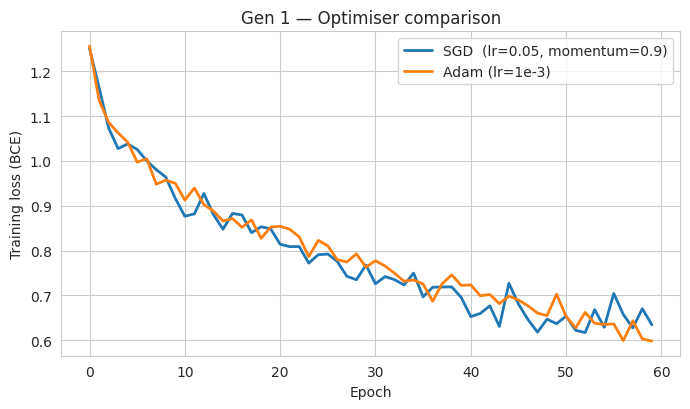

DNN (Adam): {'Accuracy': 0.82, 'Precision': 0.238, 'Recall': 0.476, 'F1': 0.317}


In [9]:
# --- optimiser comparison: SGD vs Adam ---
t0 = time.time(); h_sgd,  _,        _        = train_dnn("SGD")
h_adam, m_dnn, pred_dnn = train_dnn("Adam"); dnn_time = time.time() - t0

plt.figure(figsize=(7, 4.2))
plt.plot(h_sgd,  lw=2, label="SGD  (lr=0.05, momentum=0.9)")
plt.plot(h_adam, lw=2, label="Adam (lr=1e-3)")
plt.xlabel("Epoch"); plt.ylabel("Training loss (BCE)")
plt.title("Gen 1 — Optimiser comparison"); plt.legend(); plt.tight_layout(); plt.show()
# Adam's adaptive per-parameter steps usually drop the loss faster and smoother early on;
# SGD+momentum often catches up but needs more epochs / careful LR tuning.

RESULTS["DNN (Baseline)"] = {**m_dnn, "Training Time": f"{dnn_time:.1f}s", "pred": pred_dnn}
print("DNN (Adam):", {k: round(v,3) for k,v in m_dnn.items()})

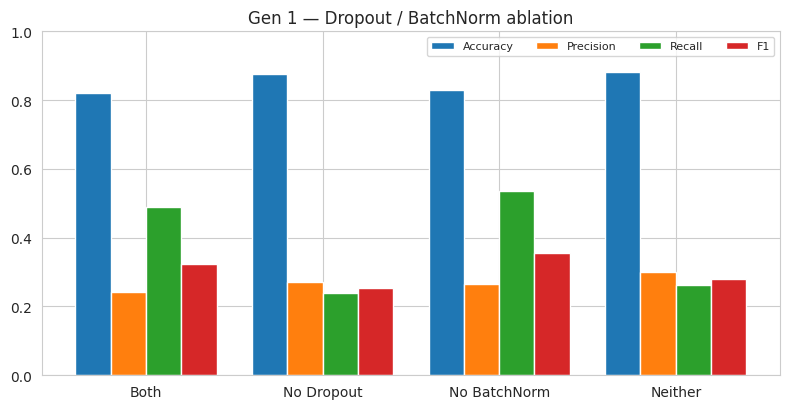

,Accuracy,Precision,Recall,F1
Both,0.821,0.243,0.488,0.324
No Dropout,0.876,0.270,0.238,0.253
No BatchNorm,0.828,0.265,0.536,0.354
Neither,0.882,0.301,0.262,0.280


In [10]:
# --- regularisation ablation: what do Dropout and BatchNorm each contribute? ---
combos = {"Both": (True, True), "No Dropout": (False, True),
          "No BatchNorm": (True, False), "Neither": (False, False)}
abl = {name: train_dnn("Adam", d, b)[1] for name, (d, b) in combos.items()}

ax = plt.subplots(figsize=(8, 4.2))[1]; x = np.arange(len(combos)); w = 0.2
for k, mname in enumerate(["Accuracy", "Precision", "Recall", "F1"]):
    ax.bar(x + k*w, [abl[n][mname] for n in combos], w, label=mname)
ax.set_xticks(x + 1.5*w); ax.set_xticklabels(list(combos)); ax.set_ylim(0, 1)
ax.set_title("Gen 1 — Dropout / BatchNorm ablation"); ax.legend(ncol=4, fontsize=8)
plt.tight_layout(); plt.show()
pd.DataFrame(abl).T.round(3)
# Read this table in the report: typically BN steadies training (less variance, can train faster),
# Dropout narrows the train/val gap (less overfitting); together they give the most reliable Recall.

## Generation 2 · Modelling the patient timeline
> *"A patient's risk is not a snapshot, it is a story told over hours."*

Now we feed the **full 24-hour sequence** to recurrent nets and compare **LSTM vs GRU vs Bi-LSTM**,
logging **train/val loss curves** and **wall-clock training time** for each.

In [11]:
class RecurrentNet(nn.Module):
    # One class covers LSTM / GRU / bidirectional just by flipping arguments.
    def __init__(self, kind="lstm", hidden=64, bidir=False):
        super().__init__()
        Cell = nn.LSTM if kind == "lstm" else nn.GRU
        self.rnn = Cell(len(VITALS), hidden, batch_first=True, bidirectional=bidir)
        self.head = nn.Linear(hidden * (2 if bidir else 1), 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :]).squeeze(1)   # decision from the final timestep's hidden state

def train_rnn(kind, bidir=False, epochs=40):
    model = RecurrentNet(kind, bidir=bidir).to(DEVICE)
    lossf = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    dl = loaders(Xseq_tr, ytr)
    Xv = torch.tensor(Xseq_te, dtype=torch.float32, device=DEVICE)
    yv = torch.tensor(yte, dtype=torch.float32, device=DEVICE)
    tr_hist, va_hist = [], []; t0 = time.time()
    for _ in range(epochs):
        model.train(); ep = 0.0
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = lossf(model(xb), yb); loss.backward(); opt.step()
            ep += loss.item()
        tr_hist.append(ep / len(dl))
        model.eval()
        with torch.no_grad(): va_hist.append(lossf(model(Xv), yv).item())
    train_time = time.time() - t0
    with torch.no_grad(): pred = (torch.sigmoid(model(Xv)) > 0.5).int().cpu().numpy()
    return tr_hist, va_hist, metric_row(yte, pred), train_time, pred

LSTM     Recall=0.429  F1=0.247  time=4.4s
GRU      Recall=0.512  F1=0.283  time=3.5s
Bi-LSTM  Recall=0.429  F1=0.232  time=4.1s


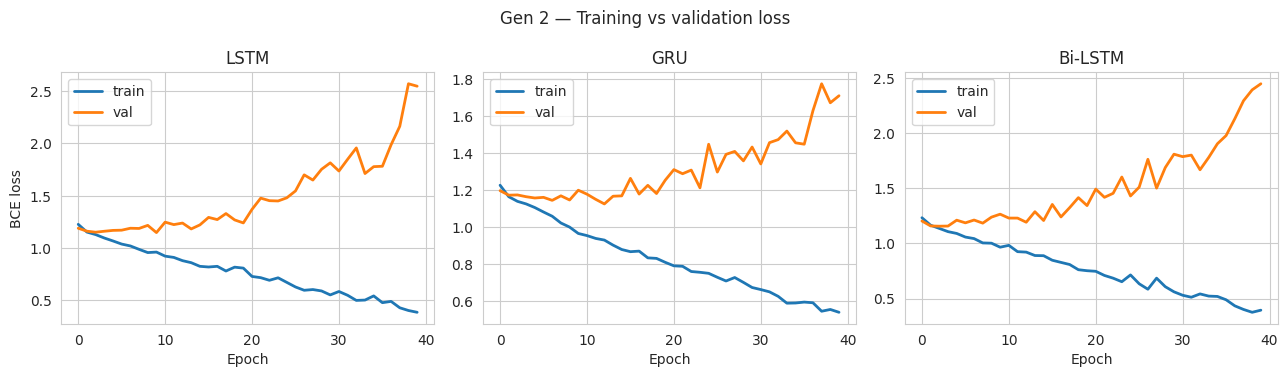

In [12]:
configs = [("LSTM", "lstm", False), ("GRU", "gru", False), ("Bi-LSTM", "lstm", True)]
rnn_curves = {}
for name, kind, bidir in configs:
    tr_h, va_h, m, tt, pred = train_rnn(kind, bidir)
    rnn_curves[name] = (tr_h, va_h)
    RESULTS[name] = {**m, "Training Time": f"{tt:.1f}s", "pred": pred}
    print(f"{name:8s} Recall={m['Recall']:.3f}  F1={m['F1']:.3f}  time={tt:.1f}s")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (name, (tr_h, va_h)) in zip(axes, rnn_curves.items()):
    ax.plot(tr_h, lw=2, label="train"); ax.plot(va_h, lw=2, label="val")
    ax.set_title(name); ax.set_xlabel("Epoch"); ax.legend()
axes[0].set_ylabel("BCE loss"); fig.suptitle("Gen 2 — Training vs validation loss")
plt.tight_layout(); plt.show()

**Real-time vs retrospective (notebook note):** the **GRU** has fewer gates/parameters, so it
trains and *infers* fastest — attractive for a bedside monitor updating every hour on modest
hardware. The **Bi-LSTM** reads the sequence forwards *and backwards*, so at any timestep it is
implicitly using **future** readings. That's fine for **retrospective** audits but **invalid for a
live early-warning system**, which by definition only has the past. So: **unidirectional GRU/LSTM
for real-time**, **Bi-LSTM only for offline analysis** — even when Bi-LSTM scores higher offline.

## Generation 3 · Reading the clinical notes with ClinicalBERT
> *"Vitals tell you numbers. Notes tell you the story. The best systems read both."*

We first build the **synthetic shift notes** (disclosed substitution — see the header), then fine-tune
**`emilyalsentzer/Bio_ClinicalBERT`** two ways: **frozen base + trainable head**, and **full
fine-tune**. We compare cost vs performance and **visualise the final-layer attention**.

In [13]:
# --- build one clinical note per patient FROM THAT PATIENT'S OWN vitals/labs ---
# (If you have MIMIC-III, replace this whole cell by loading the real note text instead.)
def describe(row_vals):
    HR, O2, Temp, SBP, MAP, Resp, Lac, WBC = row_vals
    s = []
    s.append("febrile" if Temp >= 38 else ("hypothermic" if Temp < 36 else "afebrile"))
    s.append("tachycardic" if HR > 100 else "heart rate normal")
    s.append("hypotensive" if SBP < 100 else "blood pressure stable")
    s.append("tachypneic" if Resp > 22 else "respiratory rate normal")
    s.append("hypoxic on room air" if O2 < 92 else "oxygenation adequate")
    s.append(f"lactate elevated" if Lac > 2 else "lactate normal")
    s.append("leukocytosis" if WBC > 12 else ("leukopenia" if WBC < 4 else "white count normal"))
    return "patient " + ", ".join(s)

# Use the *unscaled* last-hour readings so the words match real clinical thresholds.
last_hour = X_seq[:, -1, :]
notes = np.array([describe(last_hour[i]) for i in range(len(y))], dtype=object)
notes_tr, notes_te = notes[tr].tolist(), notes[te].tolist()
print(notes_tr[0]); print(notes_tr[1])

patient afebrile, tachycardic, blood pressure stable, respiratory rate normal, oxygenation adequate, lactate normal, white count normal
patient afebrile, heart rate normal, blood pressure stable, respiratory rate normal, oxygenation adequate, lactate normal, white count normal


In [14]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
CKPT = "emilyalsentzer/Bio_ClinicalBERT"
tok = AutoTokenizer.from_pretrained(CKPT)

# Tokeniser config: pad/truncate to 64 tokens (our notes are short), return attention mask.
def encode(texts):
    return tok(texts, padding="max_length", truncation=True, max_length=64, return_tensors="pt")
enc_tr, enc_te = encode(notes_tr), encode(notes_te)
yt_tr = torch.tensor(ytr, dtype=torch.long); yt_te = torch.tensor(yte, dtype=torch.long)

def train_bert(freeze_base, epochs=3, bs=16, lr=2e-5):
    model = AutoModelForSequenceClassification.from_pretrained(
        CKPT, num_labels=2, output_attentions=True).to(DEVICE)
    if freeze_base:                                  # frozen: only the classification head learns
        for p in model.base_model.parameters(): p.requires_grad = False
    # Weight the loss so deterioration (class 1) is penalised more when missed.
    cw = torch.tensor([1.0, float(POS_WEIGHT)], device=DEVICE)
    lossf = nn.CrossEntropyLoss(weight=cw)
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr)
    ds = TensorDataset(enc_tr["input_ids"], enc_tr["attention_mask"], yt_tr)
    dl = DataLoader(ds, batch_size=bs, shuffle=True)
    t0 = time.time()
    for _ in range(epochs):
        model.train()
        for ids, am, yb in dl:
            ids, am, yb = ids.to(DEVICE), am.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            out = model(input_ids=ids, attention_mask=am)
            loss = lossf(out.logits, yb); loss.backward(); opt.step()
    train_time = time.time() - t0
    model.eval()
    with torch.no_grad():
        out = model(input_ids=enc_te["input_ids"].to(DEVICE),
                    attention_mask=enc_te["attention_mask"].to(DEVICE))
        pred = out.logits.argmax(1).cpu().numpy()
    return model, metric_row(yte, pred), train_time, pred

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [15]:
# Strategy A: frozen base, head only (cheap, fast — good when data/compute are scarce)
m_fz_model, m_fz, t_fz, pred_fz = train_bert(freeze_base=True)
RESULTS["ClinicalBERT (Frozen)"] = {**m_fz, "Training Time": f"{t_fz:.1f}s", "pred": pred_fz}
print("Frozen :", {k: round(v,3) for k,v in m_fz.items()}, f"({t_fz:.1f}s)")

# Strategy B: full fine-tune (expensive — every weight moves — but adapts the language model to us)
m_ft_model, m_ft, t_ft, pred_ft = train_bert(freeze_base=False)
RESULTS["ClinicalBERT (Full Fine-tune)"] = {**m_ft, "Training Time": f"{t_ft:.1f}s", "pred": pred_ft}
print("Full   :", {k: round(v,3) for k,v in m_ft.items()}, f"({t_ft:.1f}s)")
print("\nPer-class breakdown (full fine-tune):")
print(classification_report(yte, pred_ft, target_names=["Stable", "Deteriorate"], zero_division=0))

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


Frozen : {'Accuracy': 0.766, 'Precision': 0.103, 'Recall': 0.214, 'F1': 0.139} (37.8s)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Full   : {'Accuracy': 0.89, 'Precision': 0.309, 'Recall': 0.202, 'F1': 0.245} (152.7s)

Per-class breakdown (full fine-tune):
              precision    recall  f1-score   support

      Stable       0.93      0.96      0.94       871
 Deteriorate       0.31      0.20      0.24        84

    accuracy                           0.89       955
   macro avg       0.62      0.58      0.59       955
weighted avg       0.87      0.89      0.88       955



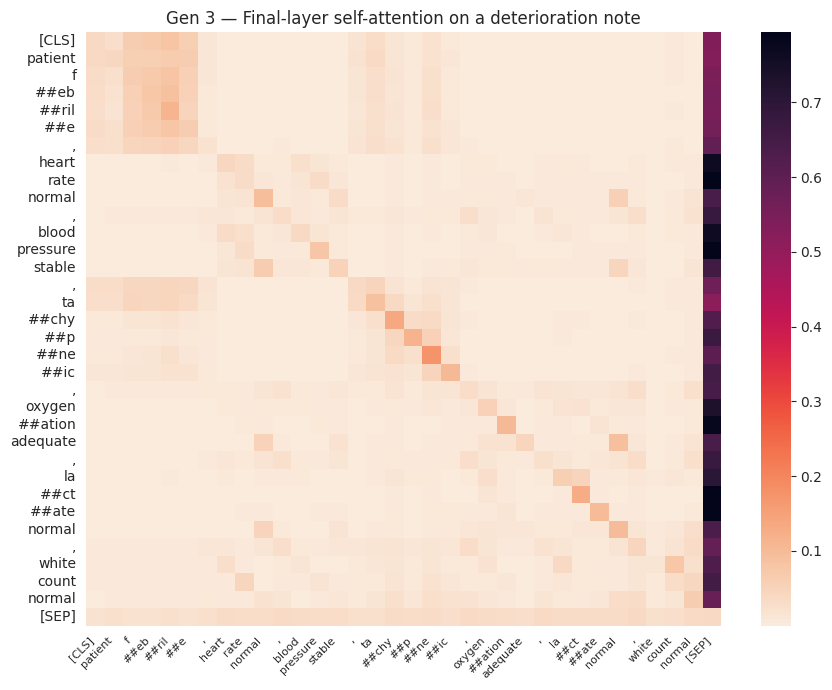

Most-attended terms: ['[SEP]', '##ril', '##ne', '##eb', '##chy', 'f', '##e', 'ta', 'normal', 'normal']


In [16]:
# --- attention visualisation: which words did the model lean on? ---
# Pull the final-layer attention for one deteriorating patient and heatmap it.
sample = next(n for n, lab in zip(notes_te, yte) if lab == 1)
enc1 = encode([sample])
with torch.no_grad():
    out = m_ft_model(input_ids=enc1["input_ids"].to(DEVICE),
                     attention_mask=enc1["attention_mask"].to(DEVICE))
last_layer = out.attentions[-1][0].mean(0).cpu().numpy()       # average over heads
tokens = tok.convert_ids_to_tokens(enc1["input_ids"][0])
keep = [i for i, t in enumerate(tokens) if t not in ("[PAD]",)]
A = last_layer[np.ix_(keep, keep)]; toks = [tokens[i] for i in keep]

plt.figure(figsize=(9, 7))
sns.heatmap(A, xticklabels=toks, yticklabels=toks, cmap="rocket_r")
plt.title("Gen 3 — Final-layer self-attention on a deterioration note")
plt.xticks(rotation=45, ha="right", fontsize=8); plt.tight_layout(); plt.show()

# Rank tokens by how much attention they *receive* — these are the model's "warning words".
importance = A.mean(0)
top = sorted(zip(toks, importance), key=lambda z: -z[1])[:10]
print("Most-attended terms:", [t for t, _ in top])

## Unified comparison · all six models

In [17]:
order = ["DNN (Baseline)", "LSTM", "Bi-LSTM", "GRU",
         "ClinicalBERT (Frozen)", "ClinicalBERT (Full Fine-tune)"]
tbl = pd.DataFrame({m: {k: RESULTS[m][k] for k in ["Accuracy","Precision","Recall","F1","Training Time"]}
                    for m in order}).T
for c in ["Accuracy","Precision","Recall","F1"]: tbl[c] = tbl[c].astype(float).round(3)
print("="*70); print("UNIFIED MODEL COMPARISON"); print("="*70)
tbl

UNIFIED MODEL COMPARISON


,Accuracy,Precision,Recall,F1,Training Time
DNN (Baseline),0.820,0.238,0.476,0.317,16.6s
LSTM,0.771,0.174,0.429,0.247,4.4s
Bi-LSTM,0.750,0.159,0.429,0.232,4.1s
GRU,0.772,0.195,0.512,0.283,3.5s
ClinicalBERT (Frozen),0.766,0.103,0.214,0.139,37.8s
ClinicalBERT (Full Fine-tune),0.890,0.309,0.202,0.245,152.7s


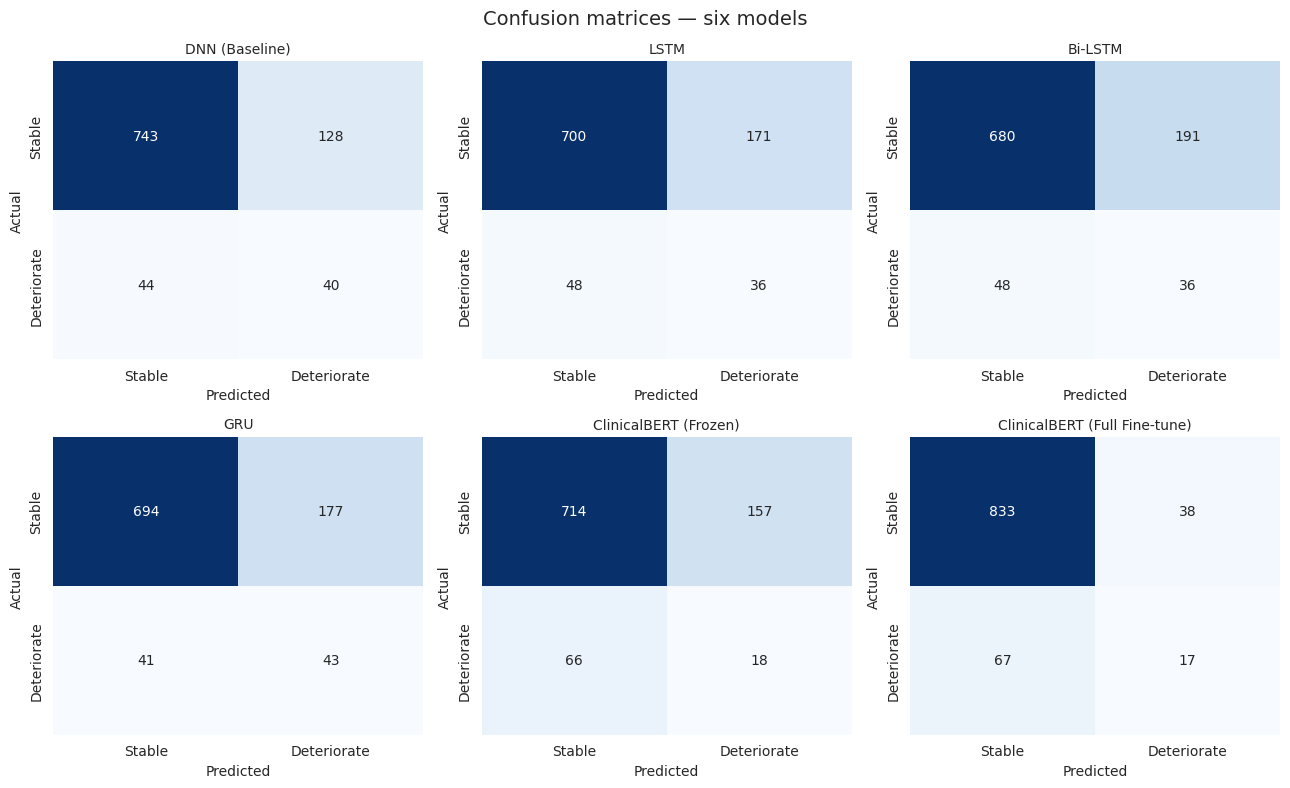

In [18]:
# Confusion matrices, all six side by side.
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, name in zip(axes.flat, order):
    cm = confusion_matrix(yte, RESULTS[name]["pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Stable","Deteriorate"], yticklabels=["Stable","Deteriorate"])
    ax.set_title(name, fontsize=10); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
fig.suptitle("Confusion matrices — six models", fontsize=14)
plt.tight_layout(); plt.show()
# In the report, read the bottom-left cell of each matrix (false negatives = missed deteriorations).
# That cell, not raw accuracy, is what decides whether a model is safe to deploy.

---
### What this notebook demonstrates
* **Gen 1** sets a floor and forces the Recall-first mindset.
* **Gen 2** shows that *sequence* beats *snapshot*, and that **bidirectionality is a deployment trap**
  for live monitoring even when it wins offline.
* **Gen 3** shows transfer learning from biomedical text, and that **full fine-tune** generally beats
  a **frozen** head once you can afford it — with attention maps giving the clinician a *why*.

See `report.pdf` for the full analysis addressed to the CMO and CTO.